## Initialize

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Data Processing
After importing the data, I need to get more information about the dataset

In [3]:
train_df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


So the image is flattened and stored in a csv file with a label for the **number** and 784 pixels means a dimension of **28x28** and each pixel has a value going from 0 to 254 indicate its color.<br>
Thus, I will separate the data into 2 parts **y_train** for the label and **X_train** for the pixels

In [4]:
y= train_df['label']
X = train_df.drop(columns=['label'])
print(X.shape)

(42000, 784)


From the shape of **X_train** there are a total of 42000 images in the dataset.<br>
Since the image is flatted out as a string of number, now I need to transform it back to a 2D image with the function **reshape**. However I need to add another layer to indicate that these image only use **1 layer of color**. Also I need to change the color value to be in the range of **(0 ,1)**

In [5]:
X = X.values/255
X = X.reshape(-1, 28, 28, 1)

In [6]:
X[0].shape

(28, 28, 1)

## Model training
After processing the data, it's time to create the model to train with this dataset. For this one, I will create a **Convolutional Neural Network (CNN)** by using the model **keras** from library tensorflow 

In [7]:
from tensorflow.keras import datasets, layers, models

2026-02-23 22:51:36.441191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771887096.599114      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771887096.645640      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771887097.094758      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771887097.094794      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771887097.094797      17 computation_placer.cc:177] computation placer alr

To train the model I also need to split the data into train and validation dataset

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)

In [9]:
# Create the brain
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-23 22:51:59.341067: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val))

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8506 - loss: 0.4622 - val_accuracy: 0.9718 - val_loss: 0.0897
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9809 - loss: 0.0611 - val_accuracy: 0.9796 - val_loss: 0.0636
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9885 - loss: 0.0365 - val_accuracy: 0.9850 - val_loss: 0.0523
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9899 - loss: 0.0297 - val_accuracy: 0.9839 - val_loss: 0.0530
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9915 - loss: 0.0237 - val_accuracy: 0.9854 - val_loss: 0.0508


Next I will plot the graph to understand the evolution of my training

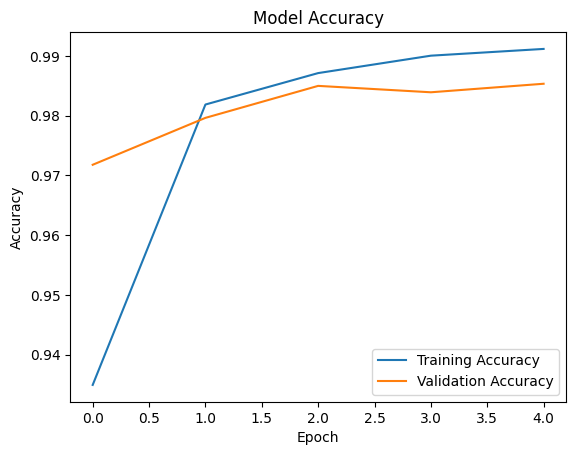

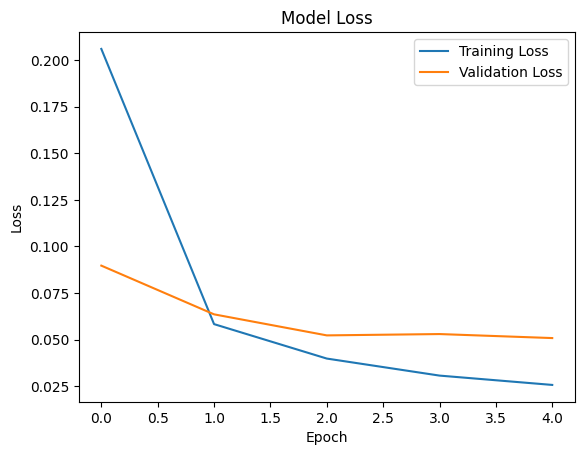

In [12]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

From the graph, I can see that
To know if the model get confused at what value, I will show the confusion matrix of model

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


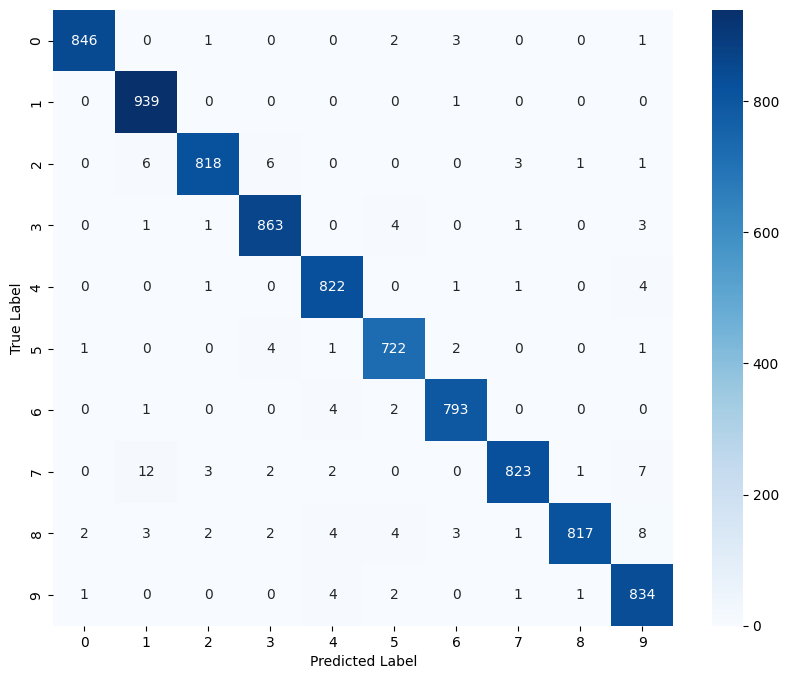

In [13]:
from sklearn.metrics import confusion_matrix

# 1. Get the model's predictions on your validation data
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# 2. Compute the matrix
cm = confusion_matrix(y_val, y_pred_classes)

# 3. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

From the confusion matrix, the model still has some small confusion between some numbers such as 6/9 and 8. Now I will increase the performance of model by adding addition layers to the network.<br>
First, I will add an **augmentation** layer, this layer makes random changes in data during training, this force the model to learn the **skeleton** of number not just the location.

In [14]:
import tensorflow as tf
data_augmentation = tf.keras.Sequential([
  layers.RandomRotation(0.1),  # Rotate by up to 10%
  layers.RandomZoom(0.1),      # Zoom in/out by 10%
  layers.RandomTranslation(0.1, 0.1) # Shift horizontally/vertically
])

Next, I will create the version 2 model with another two layers: **batch normalization** to make the data pass at the same scale increasing computation speed and **drop out** to force the neuron to not depend on others and prevent memorizing

In [15]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    data_augmentation, # Plug in the augmentation
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(), # Keep the math stable
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # 50% of neurons sleep each turn
    layers.Dense(10, activation='softmax')
])

I also add a **learning rate scheduler** so the model learn slower when the accuracy stop improving

In [16]:
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train for longer since augmentation makes it harder to learn
model.fit(X_train, y_train, epochs=20,  validation_data=(X_val, y_val), callbacks=[lr_reducer])

Epoch 1/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.6411 - loss: 1.1190 - val_accuracy: 0.9529 - val_loss: 0.1582 - learning_rate: 0.0010
Epoch 2/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.8919 - loss: 0.3486 - val_accuracy: 0.9775 - val_loss: 0.0830 - learning_rate: 0.0010
Epoch 3/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - accuracy: 0.9237 - loss: 0.2429 - val_accuracy: 0.9770 - val_loss: 0.0900 - learning_rate: 0.0010
Epoch 4/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - accuracy: 0.9384 - loss: 0.2151 - val_accuracy: 0.9794 - val_loss: 0.0756 - learning_rate: 0.0010
Epoch 5/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - accuracy: 0.9440 - loss: 0.1838 - val_accuracy: 0.9657 - val_loss: 0.1217 - learning_rate: 0.0010
Epoch 6/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - accuracy: 0.9496 - loss: 0.1610 - val_accuracy: 0.9806 - val_loss: 0.0751 - learning_rate: 0.0010
Epoch 7/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accura

## Submission

Now that the model has worked, it's time to submit <br>
First, I need to repeat the same step for data processing

In [18]:
test_df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')

X_test = test_df.values/255
X_test = X_test.reshape(-1, 28, 28, 1)
X_test[0].shape

(28, 28, 1)

Then this time instead of training the model, I will use predict which give the probability of each label and then I will select the highest one.

In [19]:
predictions = model.predict(X_test)
final_labels = np.argmax(predictions, axis=1)

submission = pd.DataFrame({
    "ImageId": range(1, len(final_labels) + 1),
    "Label": final_labels
})
submission.to_csv("submission.csv", index=False)

875/875 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
